In [24]:
import pandas as pd

df = pd.read_csv('dados_tratados_python.csv', sep=';')
df.head()

,data,produto,categoria,regiao,estado,quantidade,receita,custo
0,03/02/2023,Monitor,Tecnologia,Nordeste,BA,7,28591.10,15868.93
1,16/09/2024,Teclado,Acessórios,Nordeste,BA,8,25551.71,13971.82
2,19/07/2023,Notebook,Tecnologia,Sudeste,SP,3,2849.66,1817.44
3,16/06/2023,Mouse,Acessórios,Nordeste,BA,5,16025.09,11416.62
4,22/01/2024,Headset,Acessórios,Centro-Oeste,DF,6,4523.11,3241.26


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   data        2000 non-null   str    
 1   produto     2000 non-null   str    
 2   categoria   2000 non-null   str    
 3   regiao      2000 non-null   str    
 4   estado      2000 non-null   str    
 5   quantidade  2000 non-null   int64  
 6   receita     2000 non-null   float64
 7   custo       2000 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 125.1 KB


In [26]:
df.describe()

,quantidade,receita,custo
count,2000.000000,2000.000000,2000.000000
mean,5.005500,13606.918880,8806.738250
std,2.598046,10191.936425,6713.436271
min,1.000000,530.950000,288.150000
25%,3.000000,5037.592500,3305.287500
50%,5.000000,11014.205000,6926.260000
75%,7.000000,19580.360000,12613.307500
max,9.000000,44874.820000,33864.280000


In [27]:
df.head()

,data,produto,categoria,regiao,estado,quantidade,receita,custo
0,03/02/2023,Monitor,Tecnologia,Nordeste,BA,7,28591.10,15868.93
1,16/09/2024,Teclado,Acessórios,Nordeste,BA,8,25551.71,13971.82
2,19/07/2023,Notebook,Tecnologia,Sudeste,SP,3,2849.66,1817.44
3,16/06/2023,Mouse,Acessórios,Nordeste,BA,5,16025.09,11416.62
4,22/01/2024,Headset,Acessórios,Centro-Oeste,DF,6,4523.11,3241.26


## Entendimento inicial dos dados

Os dados foram carregados com sucesso. Nesta etapa inicial, foi possível observar a estrutura das variáveis, tipos de dados e possíveis inconsistências que serão tratadas ao longo da análise.


In [28]:
df['data'] = pd.to_datetime(df['data'], dayfirst=True)
df.head()



,data,produto,categoria,regiao,estado,quantidade,receita,custo
0,2023-02-03,Monitor,Tecnologia,Nordeste,BA,7,28591.10,15868.93
1,2024-09-16,Teclado,Acessórios,Nordeste,BA,8,25551.71,13971.82
2,2023-07-19,Notebook,Tecnologia,Sudeste,SP,3,2849.66,1817.44
3,2023-06-16,Mouse,Acessórios,Nordeste,BA,5,16025.09,11416.62
4,2024-01-22,Headset,Acessórios,Centro-Oeste,DF,6,4523.11,3241.26


In [29]:
df['mes'] = df['data'].dt.month
df['ano'] = df['data'].dt.year

In [30]:
df['receita'].sum()

np.float64(27213837.759999998)

In [31]:
df.groupby('mes')['receita'].sum()

mes
1     2603293.59
2     2081054.73
3     1862276.44
4     2494020.93
5     2353489.72
6     2184333.24
7     2289798.63
8     2480380.52
9     1841095.11
10    2096852.15
11    2459504.49
12    2467738.21
Name: receita, dtype: float64

In [32]:
df.groupby('produto')['quantidade'].sum().sort_values(ascending=False)

produto
Notebook      1792
Teclado       1723
Monitor       1678
Headset       1667
Mouse         1635
Smartphone    1516
Name: quantidade, dtype: int64

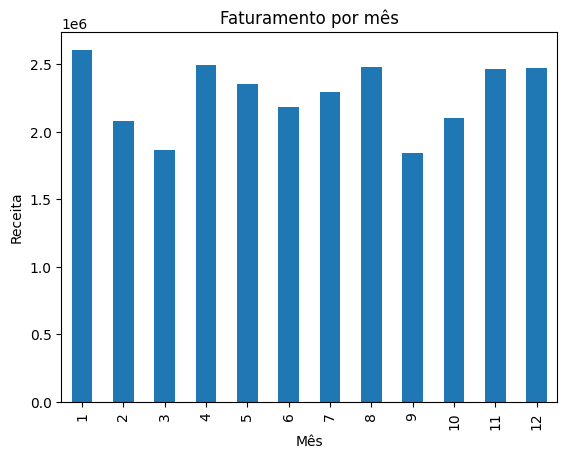

In [33]:
import matplotlib.pyplot as plt

df.groupby('mes')['receita'].sum().plot(kind='bar')
plt.title('Faturamento por mês')
plt.xlabel('Mês')
plt.ylabel('Receita')
plt.show()

## Análise dos dados

Foi possível observar que o faturamento varia ao longo dos meses, indicando possíveis sazonalidades. Além disso, alguns produtos se destacam em volume de vendas, o que pode indicar maior demanda ou aceitação no mercado.

## Insights

Observa-se que o faturamento apresenta variações ao longo dos meses, com alguns períodos apresentando desempenho superior. Isso pode indicar sazonalidade nas vendas ou influência de fatores externos, como datas comemorativas ou campanhas comerciais.

Meses com menor faturamento podem representar oportunidades de melhoria estratégica, como ações promocionais ou ajustes na oferta de produtos.

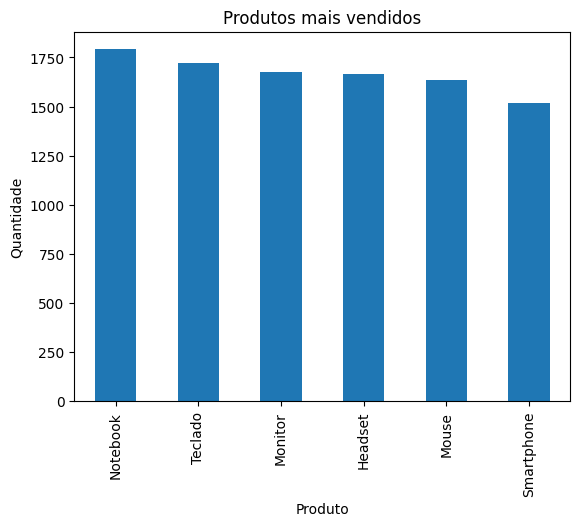

In [34]:
df.groupby('produto')['quantidade'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Produtos mais vendidos')
plt.xlabel('Produto')
plt.ylabel('Quantidade')
plt.show()

## Análise de produtos

Foi possível identificar quais produtos possuem maior volume de vendas, indicando maior aceitação no mercado. Esses produtos podem ser considerados estratégicos para o negócio, podendo receber maior investimento ou destaque em campanhas.